# SMARTS Overlay Explorer

This notebook combines one or more QM input files, rebuilds the OpenFF 2.3.0 comparisons, and overlays multiple SMARTS selections on the same QM reference distributions.

Use indexed SMARTS so only the requested geometry is measured:
- Bonds: provide SMARTS with exactly two mapped atoms (`:1`, `:2`).
- Angles: provide SMARTS with exactly three mapped atoms (`:1`, `:2`, `:3`), even if the SMARTS has additional unmapped atoms.

Edit `BOND_SMARTS_PATTERNS` and `ANGLE_SMARTS_PATTERNS` below. Edit `DATA_FILES_OVERRIDE` if you want to ignore automatic file discovery under `QM_ROOT`.

**FF-parameter filtering**: set `FF_ANGLE_PARAM_IDS` and/or `FF_BOND_PARAM_IDS` to restrict the data pool to only those geometry instances that were assigned a specific force-field parameter ID (e.g. `FF_ANGLE_PARAM_IDS = {'a10'}`). The SMARTS overlay patterns then split *within* that filtered subset.

# a40 splits
```
ANGLE_SMARTS_PATTERNS = [
    '[*:1]~[#15:2]~[*:3]',
    '[#6:1]~[#15:2]~[#8:3]',
    '[#8:1]~[#15:2]~[#8:3]',
    '[#6:1]-[#15:2]=[#8:3]',
    '[#6:1]-[#15:2]-[#8:3]',
    '[#8:1]-[#15:2]=[#8:3]',
    '[#8:1]-[#15:2]-[#8:3]',
    '[*:1]-[#15:2]=[*:3]',
    '[*:1]-[#15:2]-[*:3]',
    ]

        '[*:1]~[#15:2]~[*:3]',
    '[*:1]-[#15:2]=[*:3]',
    '[*:1]-[#15:2]-[*:3]',
    '[*:1]~[#15:2]~[#1:3]',
    # '[#6:1]~[#15:2]~[#8:3]',
    # '[#8:1]~[#15:2]~[#8:3]',
    # '[#6:1]-[#15:2]=[#8:3]',
    # '[#6:1]-[#15:2]-[#8:3]',
    # '[#8:1]-[#15:2]=[#8:3]',
    # '[#8:1]-[#15:2]-[#8:3]',

    '[*:1]~[#15:2](~[#8X1,#8H])(~[#8X1,#8H])~[#8X1,#8H:3]',
    # '[#8:1]~[#15:2](~[#8])(~[#8])~[#8:3]'
```

# a10 splits
    ```
        # ("[*:1]~[#6X3:2]~[*:3]",                           "a10"),
    # ("[*:1]~[#6X3:2]-[*:3]",                           "K"),
    # ("[*:1]~[#6X3:2]=[*:3]",                           "L"),
    # ("[*:1]~[#6X3:2]:[*:3]",                           "M"),
    # ("[*:1]~[#6X3;r4,r5:2]~[*:3]",                           "N"),
    # ("[*:1]~[#6X3:2](=[#8])-[#8X2:3]",                 "a10a"),
    # ("[#1:1]-[#6X3:2]~[*:3]",                          "a11"),
    # ("[#1:1]-[#6X3:2](=[#8])-[#7:3]",                  "a11a"),
    # ("[#1:1]-[#6X3:2]-[#1:3]",                         "a12"),
    # ("[#8X1:1]~[#6X3:2]~[#8:3]",                       "a15"),
    # ("[#8X1:1]~[#6X3:2]~[#8X1:3]",                     "a15a"),
    # ("[*:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]):2]~[*:3]",    "a20"),
    # ("[#1:1]-[#7X3$(*~[#6X3,#6X2,#7X2+0]):2]-[*:3]",   "a21"),
    # ("[*;r3:1]~;@[#6X3;r3:2]~;!@[*:3]",                "a4a"),
    ```

# Sulfur angles
```
("[*:1]~[#16X4:2]~[*:3]", "a31"), 
("[*:1]-[#16X4,#16X3+0:2]~[*:3]", "a32"),
("[#8X1:1]~[#16X4:2](~[#8X1,#7X2])~[#8X1:3]", "a42"),
("[*:1]~[#16X3$(*~[#8X1,#7X2]):2]~[*:3]", "a33"),
("[*:1]~[#16X3:2](~[#8X1,#7X2])~[*:3]", "a33a"),
("[*:1]~[#16X2,#16X3+1:2]~[*:3]", "a34"),
("[*:1]=[#16X2:2]=[*:3]", "a35"),  
("[*:1]=[#16X2:2]=[#8:3]", "a36"),
("[#6X3:1]-[#16X2:2]-[#6X3:3]", "a37"), 
("[#6X3:1]-[#16X2:2]-[#6X4:3]", "a38"), 
("[#6X3:1]-[#16X2:2]-[#1:3]", "a39") ```

In [ ]:
from __future__ import annotations

import gzip
import hashlib
import importlib
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from rdkit import Chem

from mlip_optimizer import evaluate_against_qm
from mlip_optimizer.data import load_records
from mlip_optimizer.io import read_optimized_sdf
from mlip_optimizer.analysis.bundle import (
    discover_qm_files,
    load_openff_bundle,
    load_bundles,
)
from mlip_optimizer.analysis.smarts_overlay import (
    normalize_patterns,
    compile_patterns,
    compile_indexed_patterns,
    collect_overlay_data,
    collect_hierarchy_overlay_data,
    metric_label,
    metric_unit,
)
from mlip_optimizer.visualization.smarts_overlay import (
    plot_actual_overlay,
    plot_qm_split_overlay,
    plot_error_overlay,
    plot_mm_qm_paired_overlay,
)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate repo root from {start}')


REPO_ROOT = find_repo_root()
SCRIPT_DIR = REPO_ROOT / 'examples' / '07_single_model_benchmark'
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from _shared import load_json_config, resolve_path

plt.style.use('seaborn-v0_8-whitegrid')

CONFIG_PATH = REPO_ROOT / 'examples' / '07_single_model_benchmark' / 'inputs' / 'compare_config.json'
POTENTIAL_NAME = 'openff-2.3.0'

# Default roots from your project layout.
QM_ROOT = REPO_ROOT / 'examples' / '01_download_datasets' / 'outputs' / 'optimization'
OPTIMIZED_ROOT = REPO_ROOT / 'examples' / '07_single_model_benchmark' / 'outputs' / 'optimized'

# Cache controls.
CACHE_ROOT = REPO_ROOT / 'examples' / '07_single_model_benchmark' / 'outputs' / 'cache' / 'qm_diffs'
USE_CACHE = True
FORCE_REBUILD_CACHE = False

# Optional overrides:
# - None: auto-discover all parquet/sdf QM files in QM_ROOT recursively
# - list[str|Path]: explicit QM files
DATA_FILES_OVERRIDE = None

# Indexed SMARTS requirements:
# - bond pattern must have exactly mapped atoms :1 and :2
# - angle pattern must have exactly mapped atoms :1, :2 and :3
# Each entry may be a plain SMARTS string or a (smarts, label) tuple.
BOND_SMARTS_PATTERNS = [
    # ("[#16:1]-[#16:2]", "b46"),
    # ("[#16X4,#16X3:1]-[#8X2:2]", "b58")
    ]


ANGLE_SMARTS_PATTERNS = [
    ("[*:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]):2]~[*:3]", "a20"),
    # ("[*:1]-[#7X3:2]-[#6X3:3]([#8X1,#6X3,#16])", "K1"),
    # ("[#7,#8,#15,#16:1]-[#7X3:2]-[#6X3:3]([#8X1,#6X3,#16])", "K2"),
    # ("[#7,#8,#15,#16:1]-[#7X3:2]-[#6X3:3]([#6X3,#16])", "K3"),
    ("[*:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]);r:2]~[*;r:3]", "R1"),
    ("[*;r:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]);r:2]~[*;r:3]", "R2"),
    # # ("[*:1]-[#7X3r:2]-[#6X3r:3]", "R1"),      # both N and C are in ring, first one is dangling
    # # ("[*;r:1]-[#7X3r:2]-[#6X3r:3]", "R2"),    # all are in ring
    # ("[*;r:1]-[#7X3;r4:2]-[#6X3r:3]", "R3"),  # N is in 4-membered ring, and C in ring 
    # ("[*;r:1]@[#7x3:2]-[#6r:3]", "R4"),     # N is bridgehead, and first atom is in the same ring as N, C is also in ring
    # ("[*;r:1]@[#7x3;r4:2]-[#6X3r:3]", "R5"),     # N is bridgehead, and in r4, beta-lactam like
]

# FF-parameter filtering (optional).
# Set FORCEFIELD_NAME and restrict data collection to specific parameter IDs.
# Examples:
#   FF_ANGLE_PARAM_IDS = {'a10'}           # only angles assigned to a10
#   FF_ANGLE_PARAM_IDS = {'a10', 'a11'}    # multiple params
#   FF_BOND_PARAM_IDS  = {'b15'}
# Leave as None to include all instances (no FF filtering).
FORCEFIELD_NAME = 'openff-2.3.0'
FF_BOND_PARAM_IDS: set[str] | None = None
FF_ANGLE_PARAM_IDS = {'a20'} #: set[str] | None = None

# High-error-only mode (optional).
# When True, restrict to geometry instances that exceeded the error threshold
# in at least one conformer — matching exactly what the comparison report's
# per-parameter violin pages show (bimodal a10 distribution etc.).
# When False (default), show all matched instances regardless of error size.
HIGH_ERROR_ONLY: bool = False

BOND_THRESHOLD = 0.1
ANGLE_THRESHOLD = 5.0
TORSION_THRESHOLD = 40.0

METRICS = ('bond', 'angle')

In [100]:
import mlip_optimizer.analysis.bundle as _bundle_mod
import mlip_optimizer.analysis.smarts_overlay as _smarts_mod
import mlip_optimizer.visualization.smarts_overlay as _vis_mod
importlib.reload(_bundle_mod)
importlib.reload(_smarts_mod)
importlib.reload(_vis_mod)

from mlip_optimizer.analysis.bundle import discover_qm_files, load_openff_bundle, load_bundles
from mlip_optimizer.analysis.smarts_overlay import (
    normalize_patterns, compile_patterns, compile_indexed_patterns,
    collect_overlay_data, collect_hierarchy_overlay_data, metric_label, metric_unit,
)
from mlip_optimizer.visualization.smarts_overlay import (
    plot_actual_overlay, plot_qm_split_overlay, plot_error_overlay, plot_mm_qm_paired_overlay,
)

2026-06-19 08:58:00,018 - mlip_optimizer.data.readers - INFO - Reading parquet: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/01_download_datasets/outputs/optimization/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0_20260306T142716/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0.parquet
2026-06-19 08:58:03,595 - mlip_optimizer.data.grouping - INFO - Grouped 2976 rows into 528 molecules (2976 total conformers)
2026-06-19 08:58:13,846 - mlip_optimizer.data.readers - INFO - Reading parquet: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/01_download_datasets/outputs/optimization/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0_20260306T142948/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0.parquet


cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0__openff-2_3_0__71e0c912541b.pkl.gz
ff cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0__ff_openff-2_3_0__be31ec05d99d.pkl.gz


2026-06-19 08:58:17,925 - mlip_optimizer.data.grouping - INFO - Grouped 2581 rows into 383 molecules (2581 total conformers)
2026-06-19 08:58:25,670 - mlip_optimizer.io - WARNING - No optimized data for molecule 277 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)
2026-06-19 08:58:26,470 - mlip_optimizer.data.readers - INFO - Reading parquet: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/01_download_datasets/outputs/optimization/OpenFF_NSP_Optimization_Set_1_Sulfur_v4_0_20260306T142817/OpenFF_NSP_Optimization_Set_1_Sulfur_v4_0.parquet


cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0__openff-2_3_0__d40d829ddb6a.pkl.gz
ff cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0__ff_openff-2_3_0__536be2587909.pkl.gz


2026-06-19 08:58:29,950 - mlip_optimizer.data.grouping - INFO - Grouped 3570 rows into 588 molecules (3570 total conformers)
2026-06-19 08:58:38,970 - mlip_optimizer.io - WARNING - No optimized data for molecule 295 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)
2026-06-19 08:58:39,079 - mlip_optimizer.io - WARNING - No optimized data for molecule 367 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)
2026-06-19 08:58:39,093 - mlip_optimizer.io - WARNING - No optimized data for molecule 375 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)


...

## SMARTS summary

,metric,pattern,smarts,matched_molecules,qm_points,value_points,error_points
0,angle,a20,"[*:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]):2]~[*:3]",606,11334,11334,11334
1,angle,K1,"[*:1]-[#7X3:2]-[#6X3:3]([#8X1,#6X3,#16])",311,3859,3859,3859
2,angle,K2,"[#7,#8,#15,#16:1]-[#7X3:2]-[#6X3:3]([#8X1,#6X3...",111,847,847,847
3,angle,K3,"[#7,#8,#15,#16:1]-[#7X3:2]-[#6X3:3]([#6X3,#16])",111,847,847,847
4,angle,R1,"[*:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]);r:2]~[*;r:3]",273,4514,4514,4514
5,angle,R2,"[*;r:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]);r:2]~[*;r:3]",185,2373,2373,2373
6,angle,R3,[*;r:1]-[#7X3;r4:2]-[#6X3r:3],25,313,313,313
7,angle,R4,[*;r:1]@[#7x3:2]-[#6r:3],23,391,391,391
8,angle,R5,[*;r:1]@[#7x3;r4:2]-[#6X3r:3],21,261,261,261


### Bond

No data available for bond
No SMARTS-split QM data available for bond
No error data available for bond
No paired MM/QM data for bond


### Angle

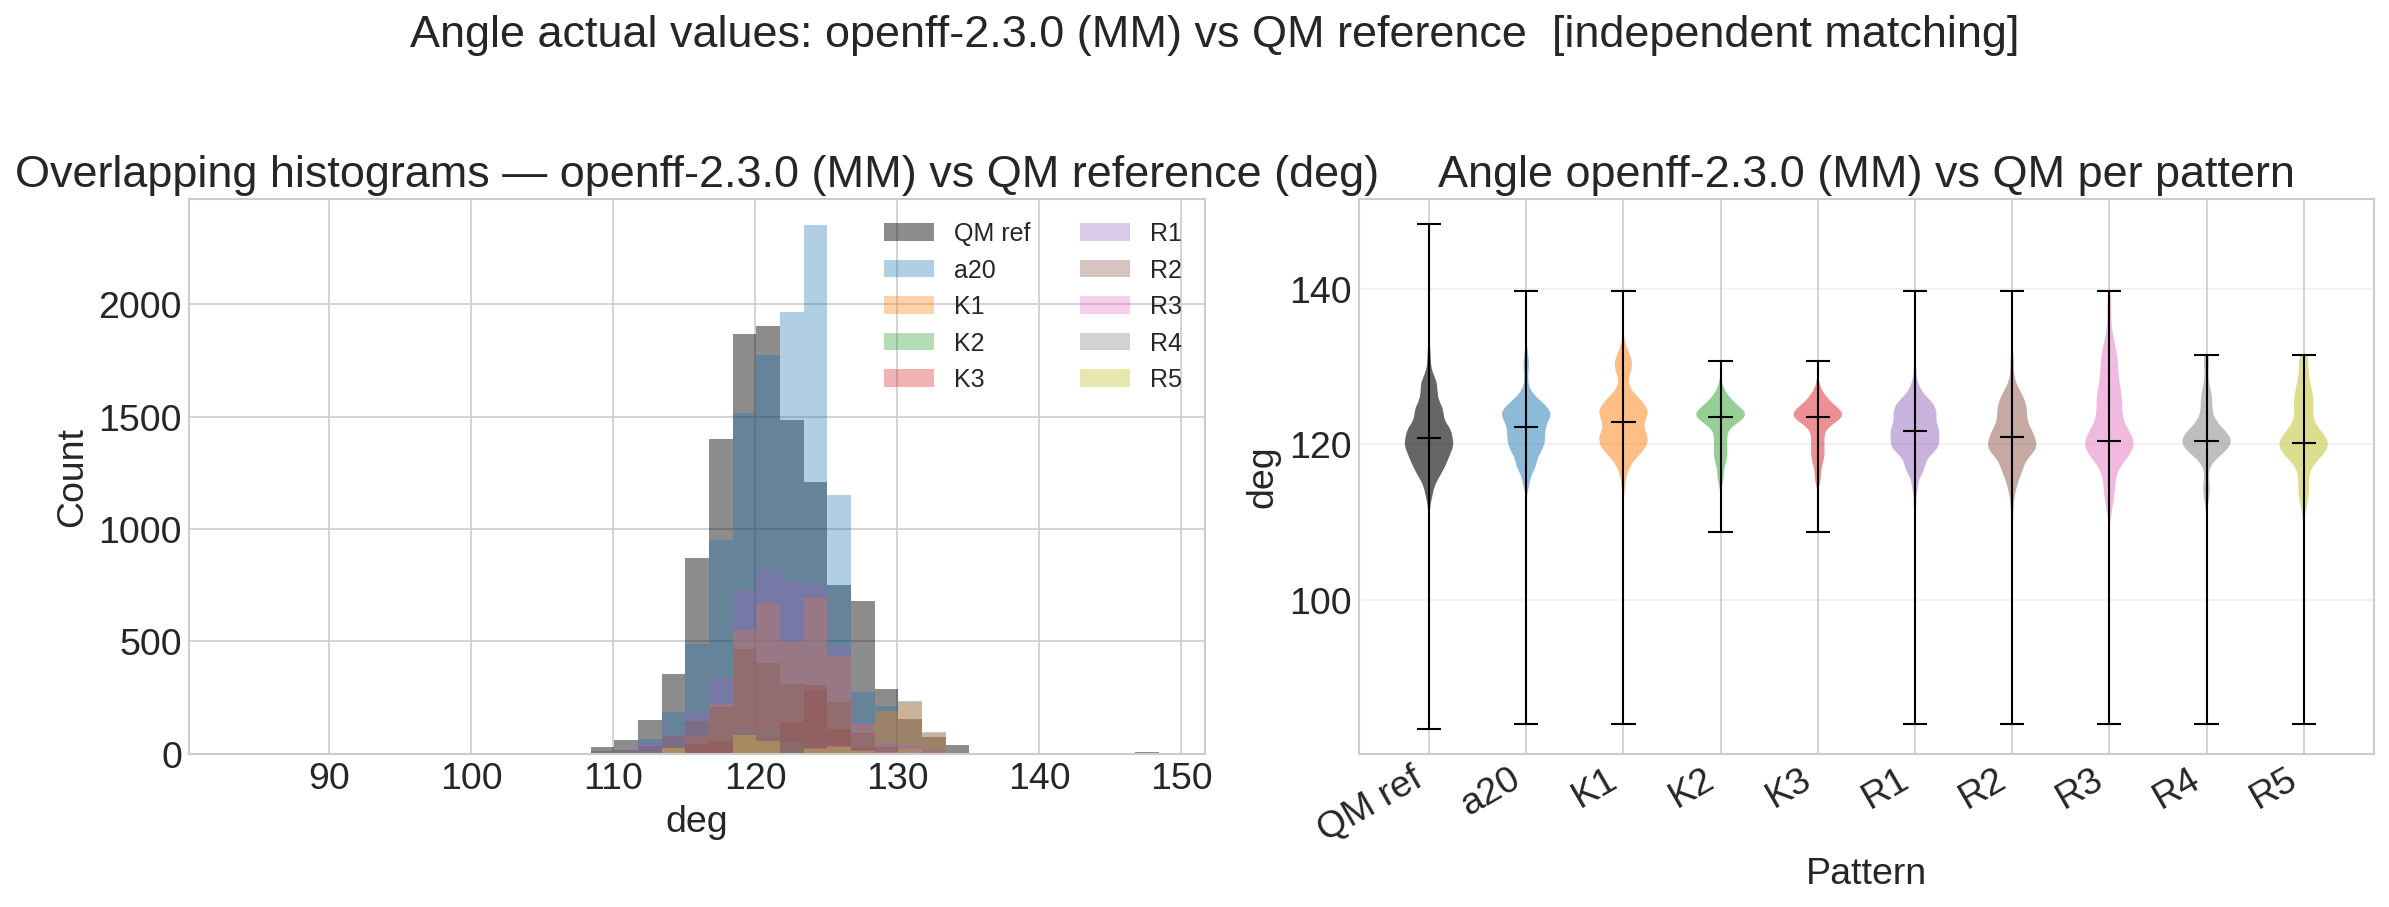

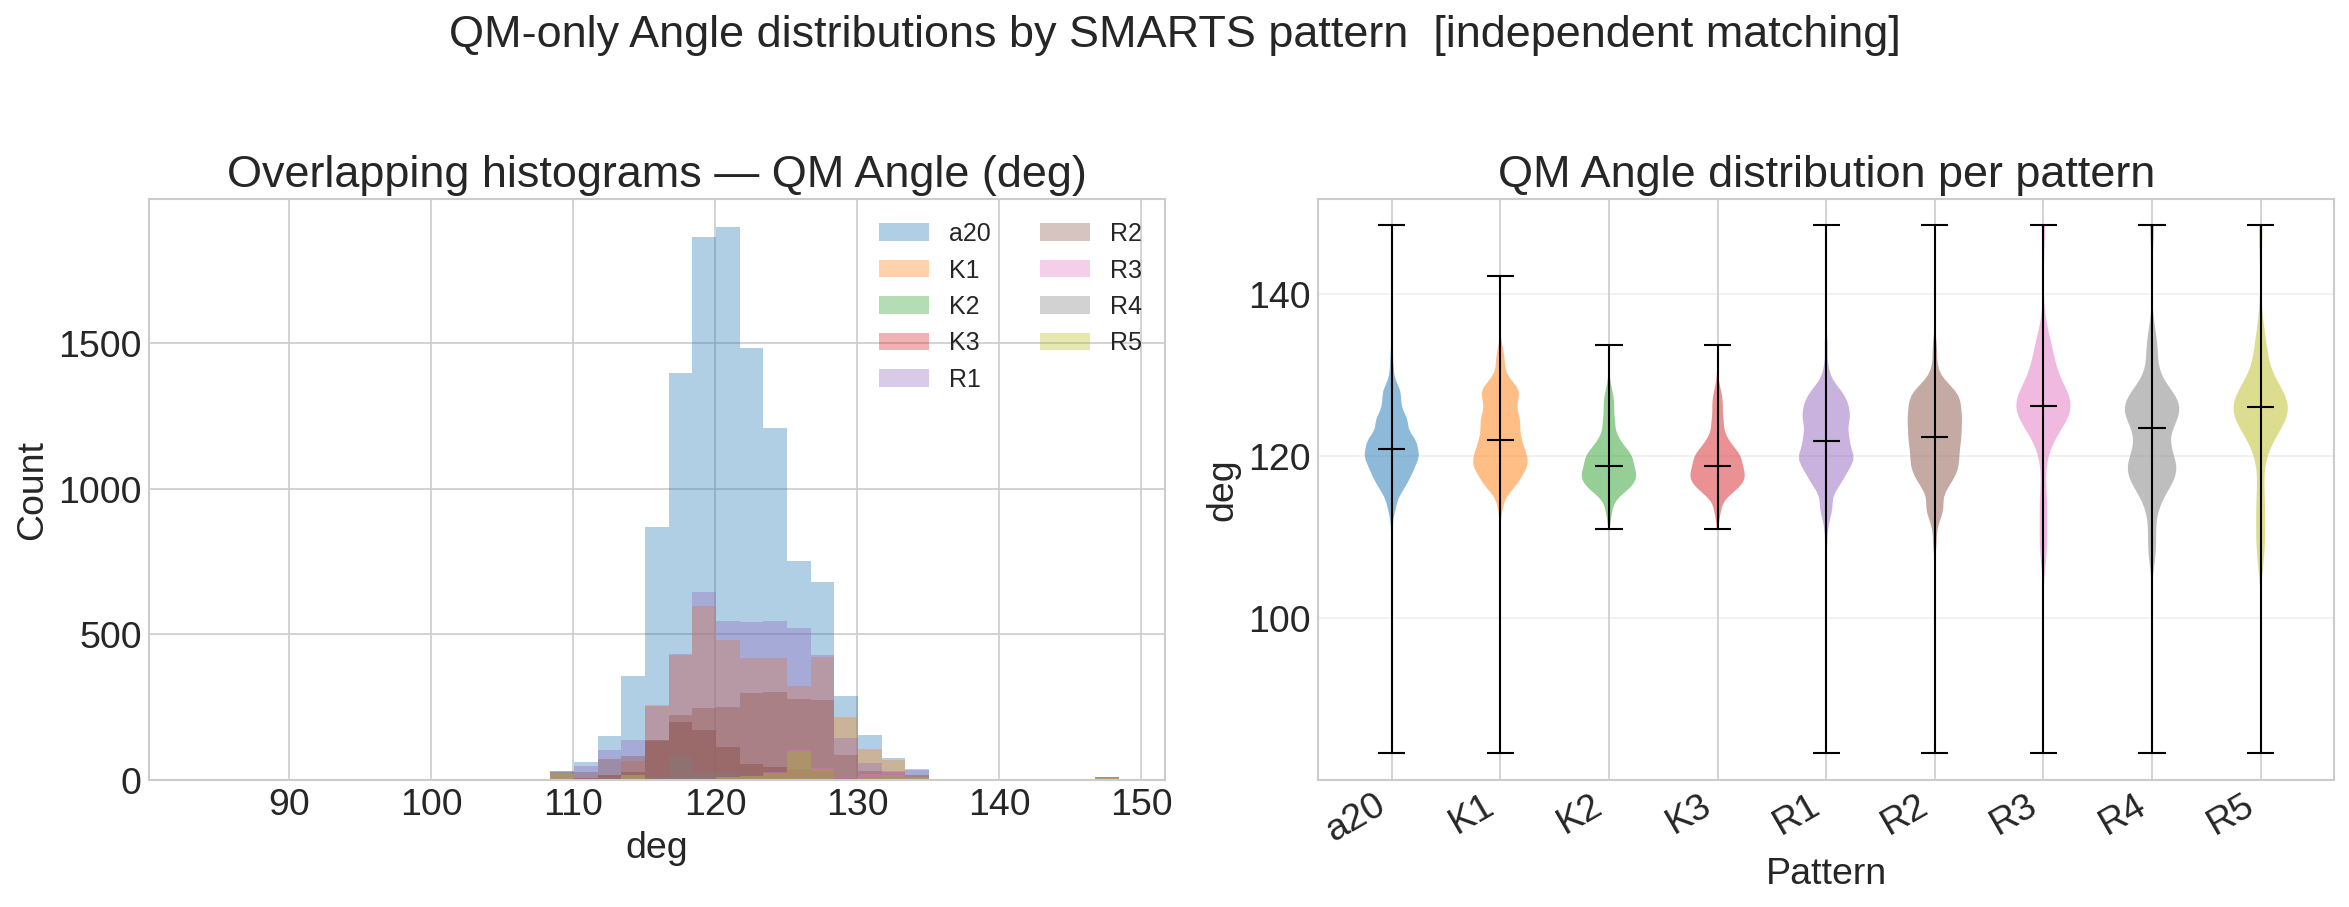

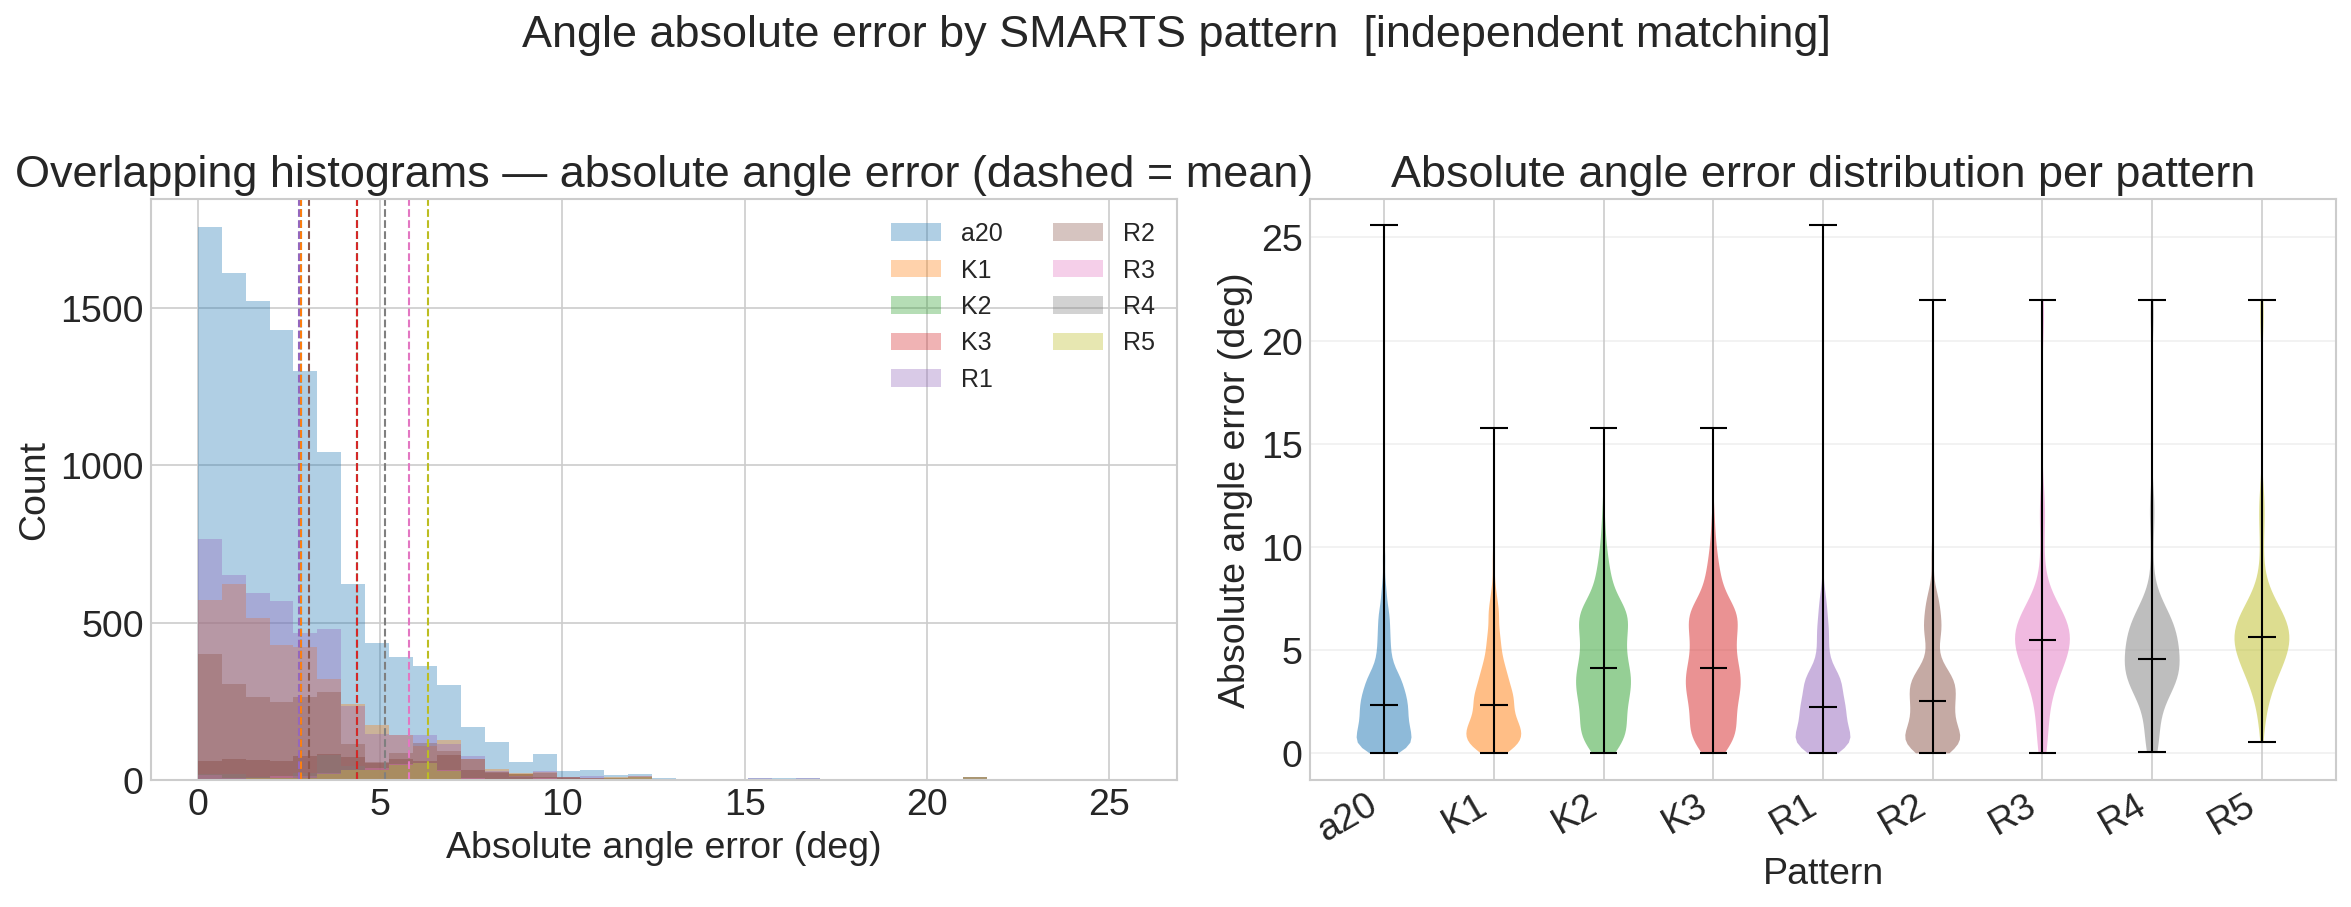

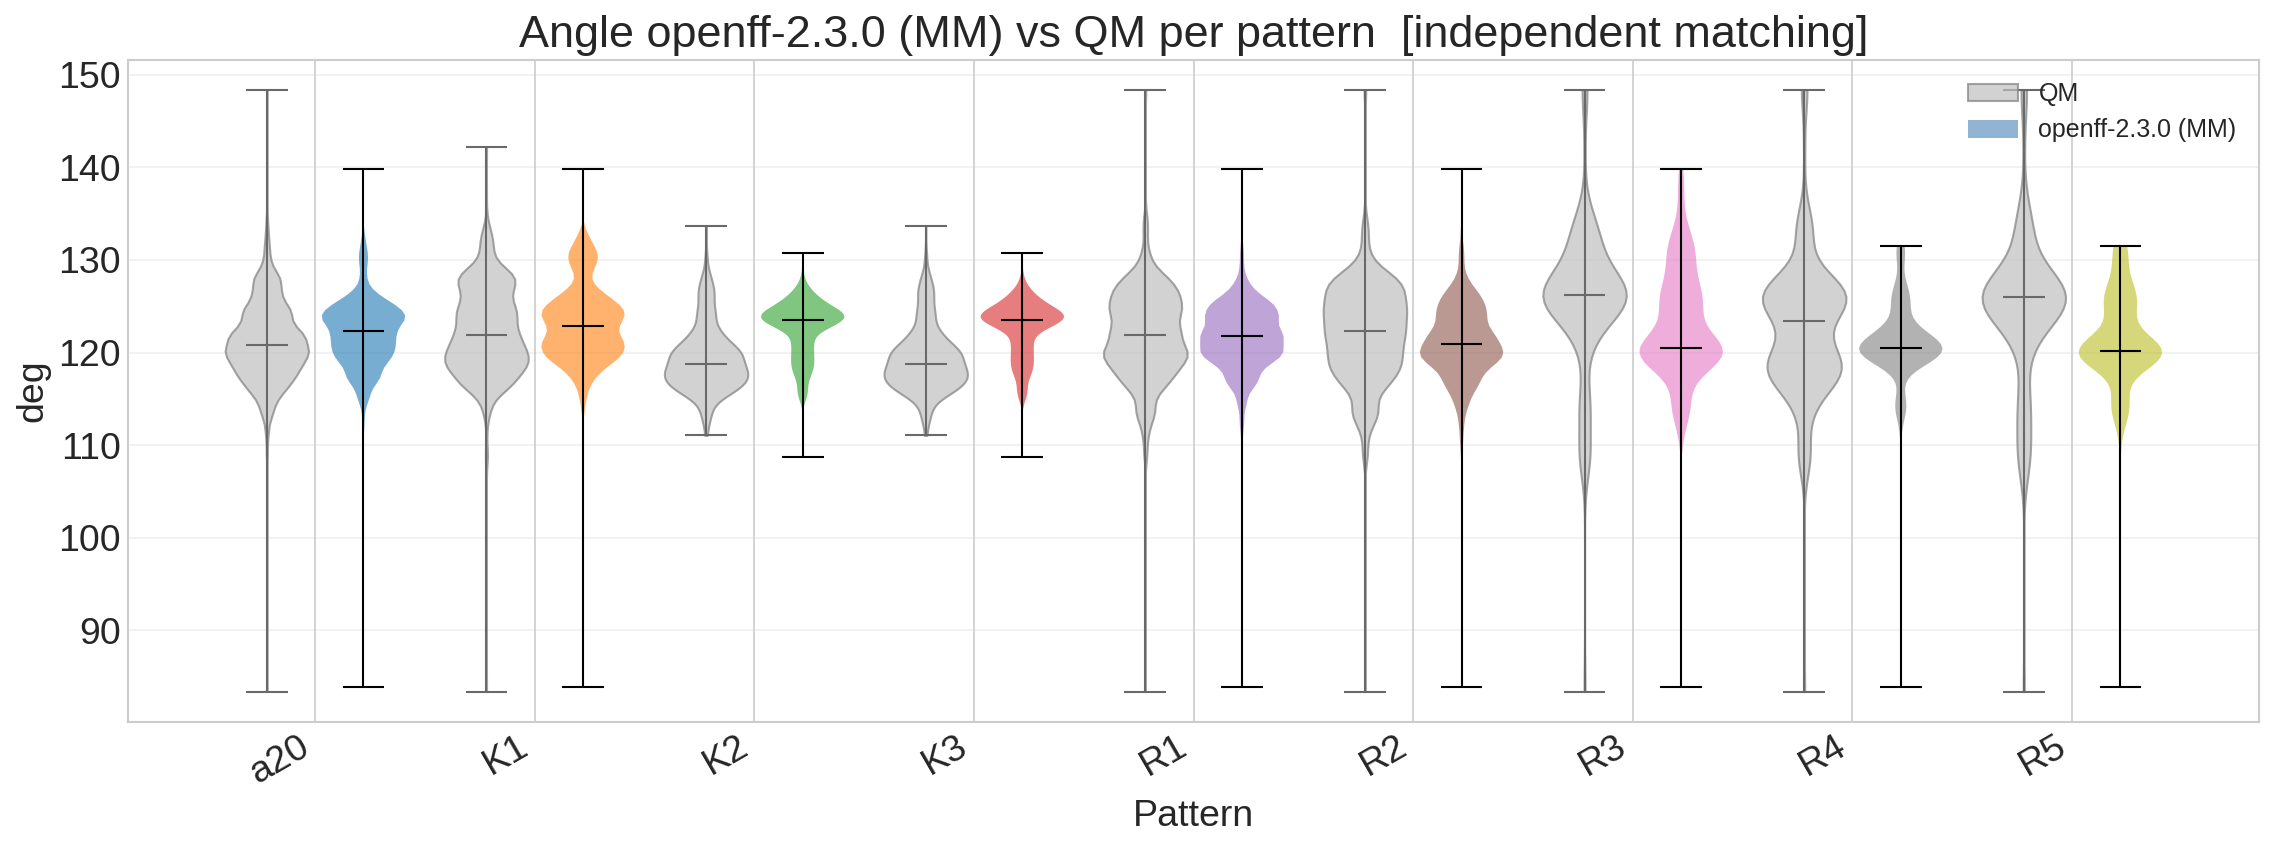

In [101]:
def run_overlay_analysis(
    bond_smarts_patterns=BOND_SMARTS_PATTERNS,
    angle_smarts_patterns=ANGLE_SMARTS_PATTERNS,
    data_files_override=DATA_FILES_OVERRIDE,
    forcefield_name=FORCEFIELD_NAME,
    ff_bond_param_ids=FF_BOND_PARAM_IDS,
    ff_angle_param_ids=FF_ANGLE_PARAM_IDS,
    high_error_only=HIGH_ERROR_ONLY,
):
    config, bundles = load_bundles(
        QM_ROOT,
        OPTIMIZED_ROOT,
        POTENTIAL_NAME,
        data_files_override=data_files_override,
        cache_root=CACHE_ROOT,
        use_cache=USE_CACHE,
        force_rebuild_cache=FORCE_REBUILD_CACHE,
        bond_threshold=BOND_THRESHOLD,
        angle_threshold=ANGLE_THRESHOLD,
        torsion_threshold=TORSION_THRESHOLD,
        label_forcefield_name=forcefield_name,
    )
    analysis, summary = collect_overlay_data(
        bundles,
        bond_smarts_patterns,
        angle_smarts_patterns,
        POTENTIAL_NAME,
        metrics=METRICS,
        forcefield_name=forcefield_name,
        ff_bond_param_ids=ff_bond_param_ids,
        ff_angle_param_ids=ff_angle_param_ids,
        high_error_only=high_error_only,
    )

    display(Markdown('## Input summary'))
    input_rows = [
        {
            'dataset': bundle['dataset_name'],
            'records': len(bundle['records']),
            'optimized_sdf': str(bundle['optimized_sdf']),
        }
        for bundle in bundles
    ]
    display(pd.DataFrame(input_rows))

    # Show active filters
    filter_rows = []
    if ff_angle_param_ids is not None:
        filter_rows.append({'filter': 'FF angle param IDs', 'value': ', '.join(sorted(ff_angle_param_ids))})
    if ff_bond_param_ids is not None:
        filter_rows.append({'filter': 'FF bond param IDs', 'value': ', '.join(sorted(ff_bond_param_ids))})
    if high_error_only:
        filter_rows.append({'filter': 'high_error_only', 'value': f'True (threshold-crossing instances only — matches comparison report)'})
    if filter_rows:
        display(Markdown('## Active filters'))
        display(pd.DataFrame(filter_rows))

    display(Markdown('## SMARTS summary'))
    display(summary)

    for metric in METRICS:
        display(Markdown(f'### {metric_label(metric)}'))
        plot_actual_overlay(analysis, metric, hierarchy=False, potential_name=POTENTIAL_NAME)
        plot_qm_split_overlay(analysis, metric, hierarchy=False)
        plot_error_overlay(analysis, metric, hierarchy=False)
        plot_mm_qm_paired_overlay(analysis, metric, hierarchy=False, potential_name=POTENTIAL_NAME)

    return config, bundles, analysis, summary


config, bundles, analysis, summary = run_overlay_analysis()

2026-06-19 08:58:54,082 - mlip_optimizer.data.readers - INFO - Reading parquet: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/01_download_datasets/outputs/optimization/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0_20260306T142716/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0.parquet
2026-06-19 08:58:57,240 - mlip_optimizer.data.grouping - INFO - Grouped 2976 rows into 528 molecules (2976 total conformers)
2026-06-19 08:59:07,406 - mlip_optimizer.data.readers - INFO - Reading parquet: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/01_download_datasets/outputs/optimization/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0_20260306T142948/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0.parquet


cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0__openff-2_3_0__71e0c912541b.pkl.gz
ff cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Nitrogen_v4_0__ff_openff-2_3_0__be31ec05d99d.pkl.gz


2026-06-19 08:59:09,793 - mlip_optimizer.data.grouping - INFO - Grouped 2581 rows into 383 molecules (2581 total conformers)
2026-06-19 08:59:17,020 - mlip_optimizer.io - WARNING - No optimized data for molecule 277 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)
2026-06-19 08:59:17,926 - mlip_optimizer.data.readers - INFO - Reading parquet: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/01_download_datasets/outputs/optimization/OpenFF_NSP_Optimization_Set_1_Sulfur_v4_0_20260306T142817/OpenFF_NSP_Optimization_Set_1_Sulfur_v4_0.parquet


cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0__openff-2_3_0__d40d829ddb6a.pkl.gz
ff cache hit  -> loaded: /home/maverick/Desktop/CNT-work/EC_Project/NSP_datasets/mlip_optimizer/examples/07_single_model_benchmark/outputs/cache/qm_diffs/OpenFF_NSP_Optimization_Set_1_Phosphorus_v4_0__ff_openff-2_3_0__536be2587909.pkl.gz


2026-06-19 08:59:23,549 - mlip_optimizer.data.grouping - INFO - Grouped 3570 rows into 588 molecules (3570 total conformers)
2026-06-19 08:59:35,284 - mlip_optimizer.io - WARNING - No optimized data for molecule 295 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)
2026-06-19 08:59:35,431 - mlip_optimizer.io - WARNING - No optimized data for molecule 367 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)
2026-06-19 08:59:35,450 - mlip_optimizer.io - WARNING - No optimized data for molecule 375 in optimized_openff-2_3_0_20260326T103257.sdf (Opt. fail)


...

## SMARTS hierarchy summary (counts are mutually exclusive)

,metric,pattern,smarts,matched_molecules,qm_points,value_points,error_points
0,angle,a20,"[*:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]):2]~[*:3]",292,4488,4488,4488
1,angle,K1,"[*:1]-[#7X3:2]-[#6X3:3]([#8X1,#6X3,#16])",134,1686,1686,1686
2,angle,K2,"[#7,#8,#15,#16:1]-[#7X3:2]-[#6X3:3]([#8X1,#6X3...",0,0,0,0
3,angle,K3,"[#7,#8,#15,#16:1]-[#7X3:2]-[#6X3:3]([#6X3,#16])",76,646,646,646
4,angle,R1,"[*:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]);r:2]~[*;r:3]",173,2141,2141,2141
5,angle,R2,"[*;r:1]~[#7X3$(*~[#6X3,#6X2,#7X2+0]);r:2]~[*;r:3]",160,1930,1930,1930
6,angle,R3,[*;r:1]-[#7X3;r4:2]-[#6X3r:3],5,52,52,52
7,angle,R4,[*;r:1]@[#7x3:2]-[#6r:3],13,130,130,130
8,angle,R5,[*;r:1]@[#7x3;r4:2]-[#6X3r:3],21,261,261,261


### Bond

No data available for bond
No SMARTS-split QM data available for bond
No error data available for bond
No paired MM/QM data for bond


### Angle

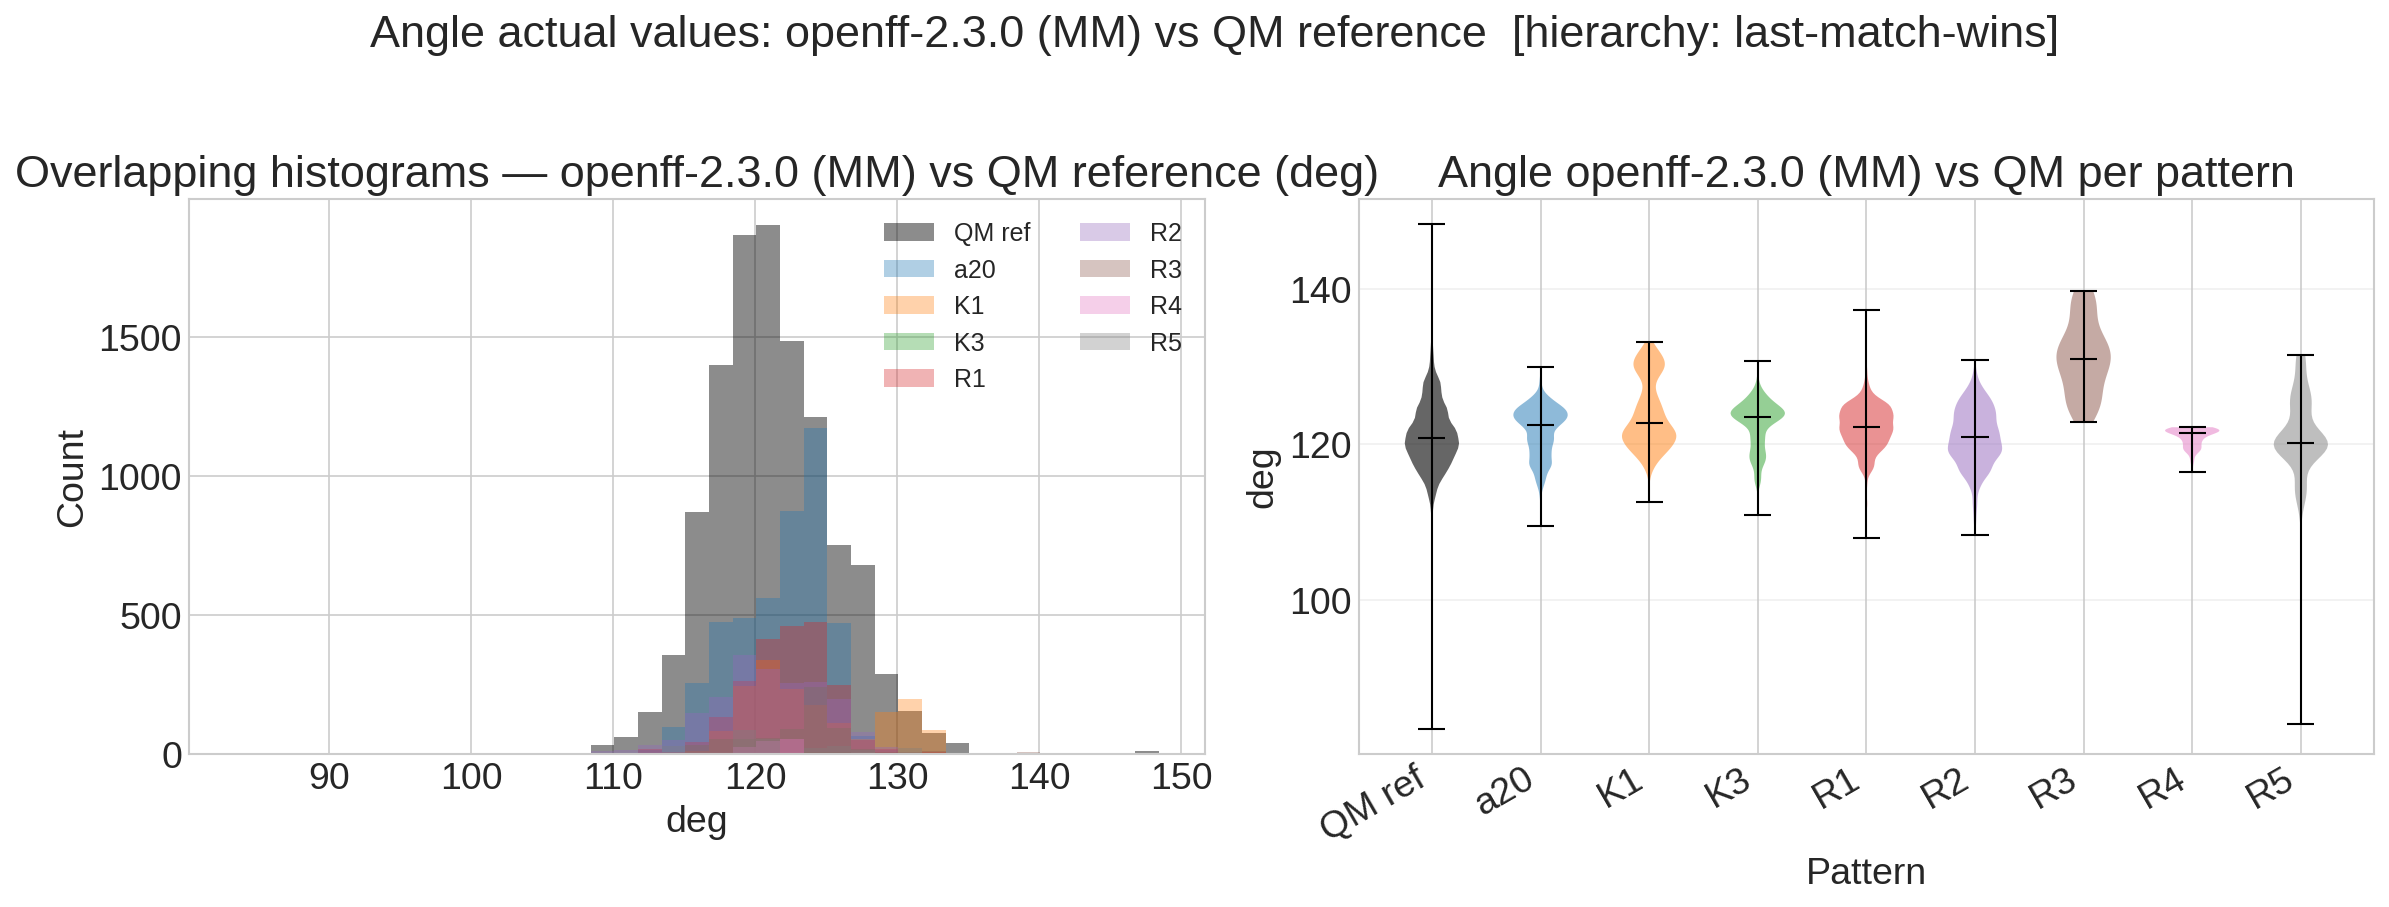

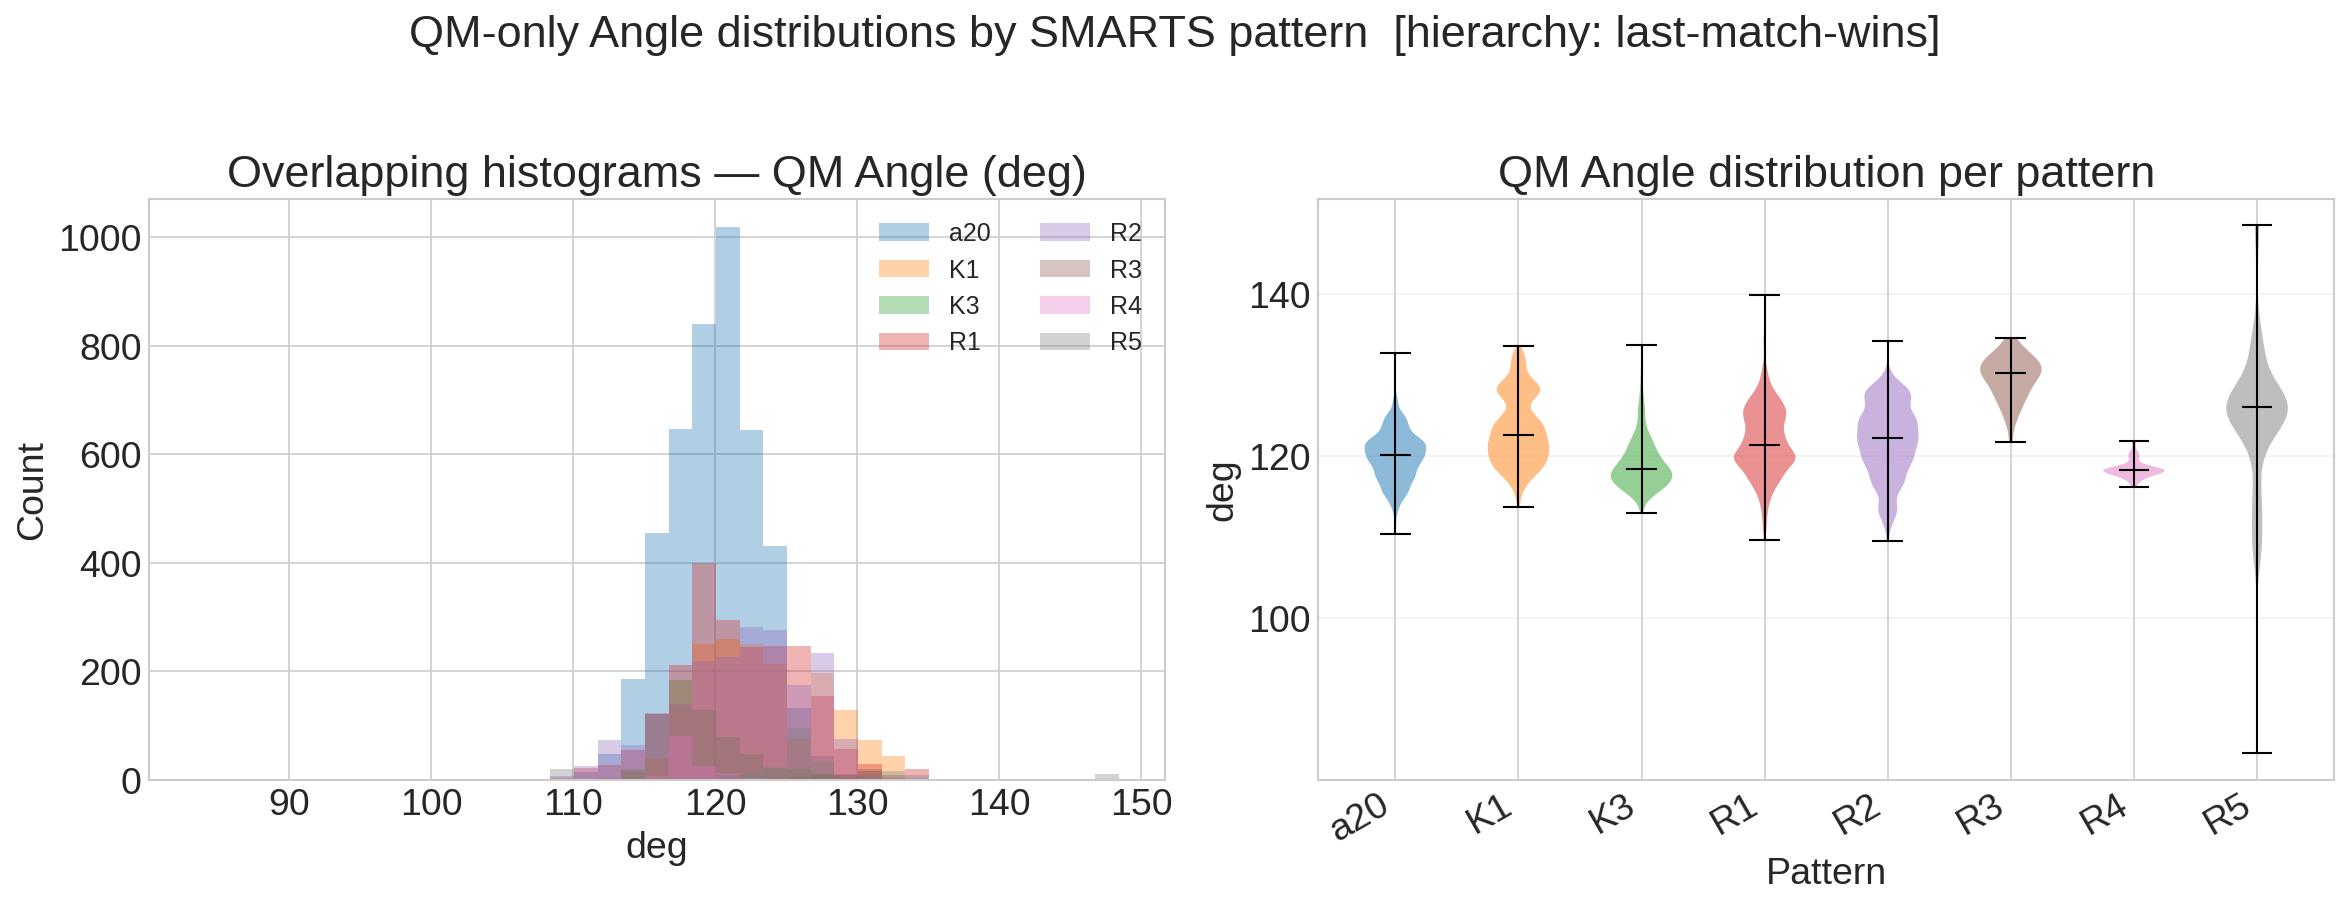

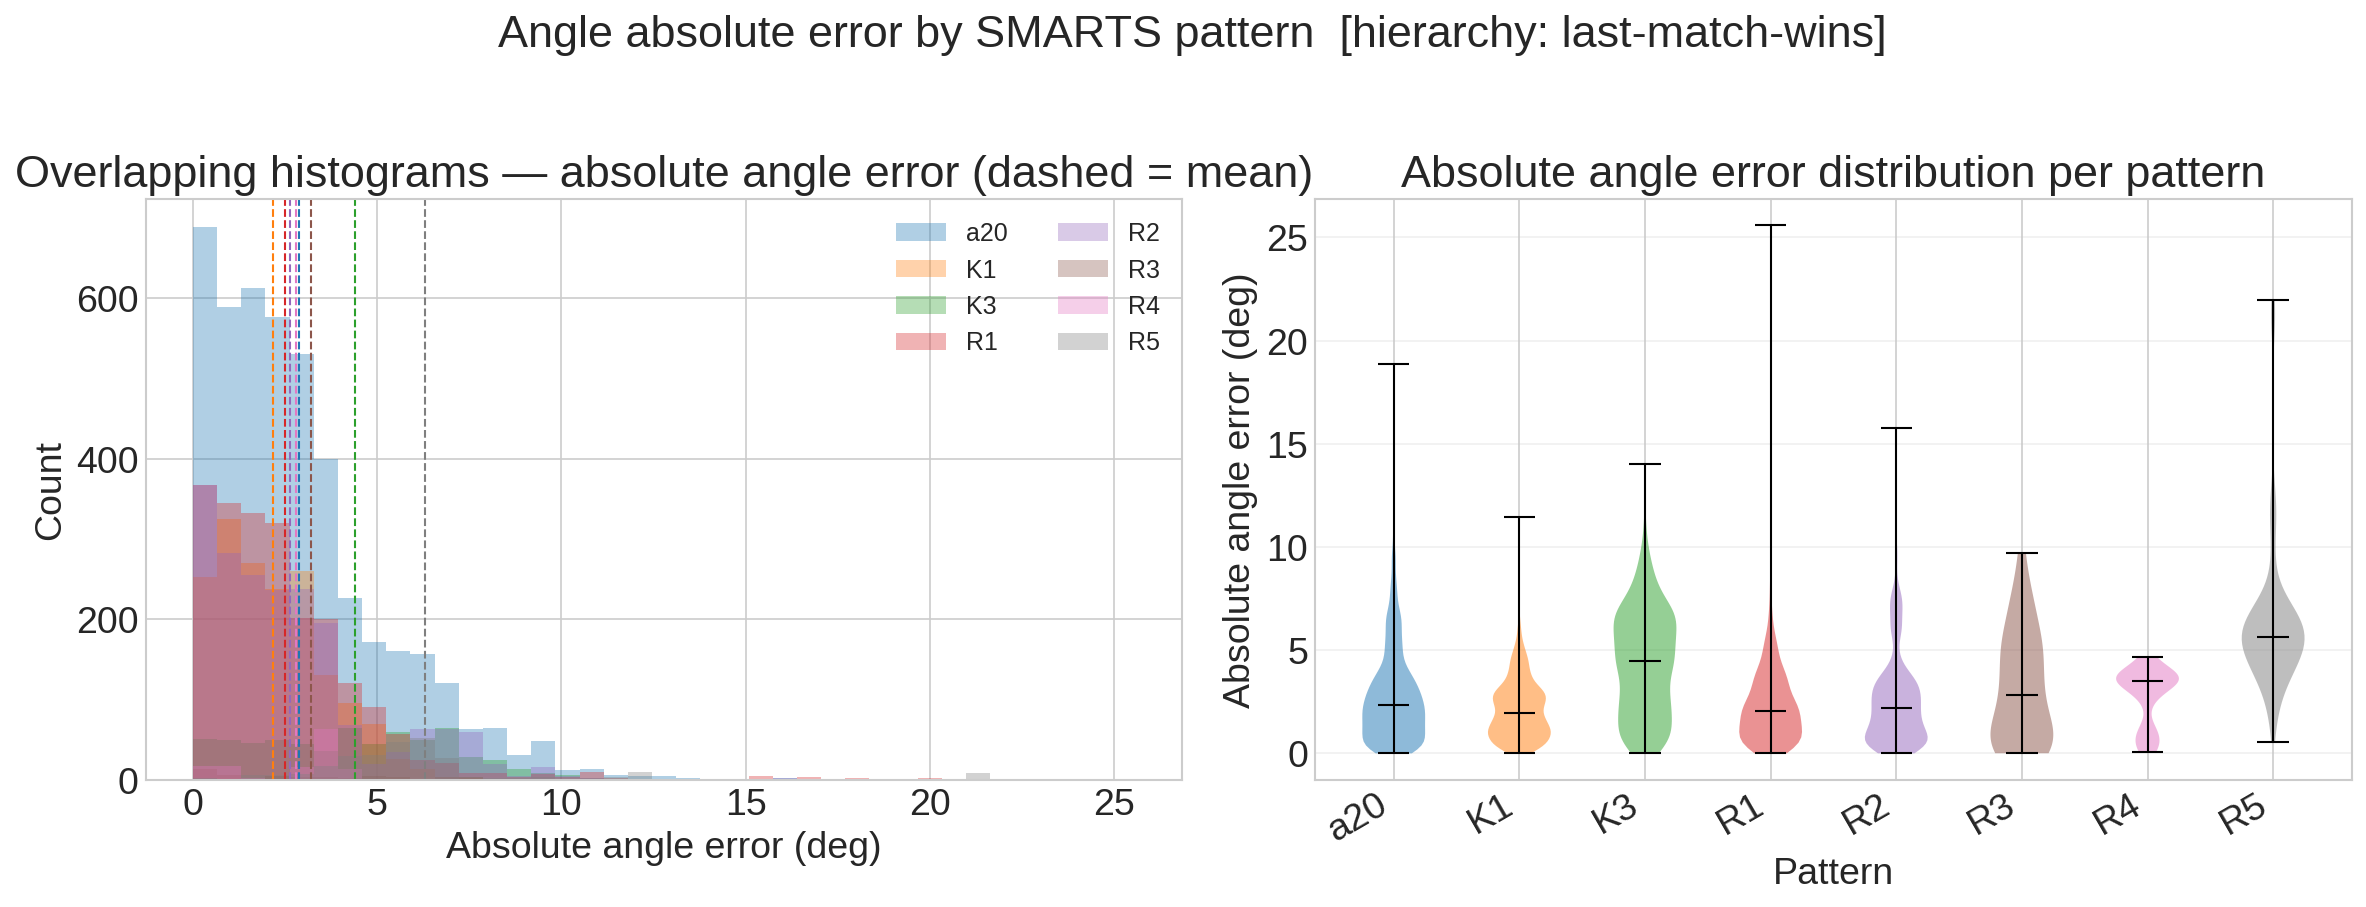

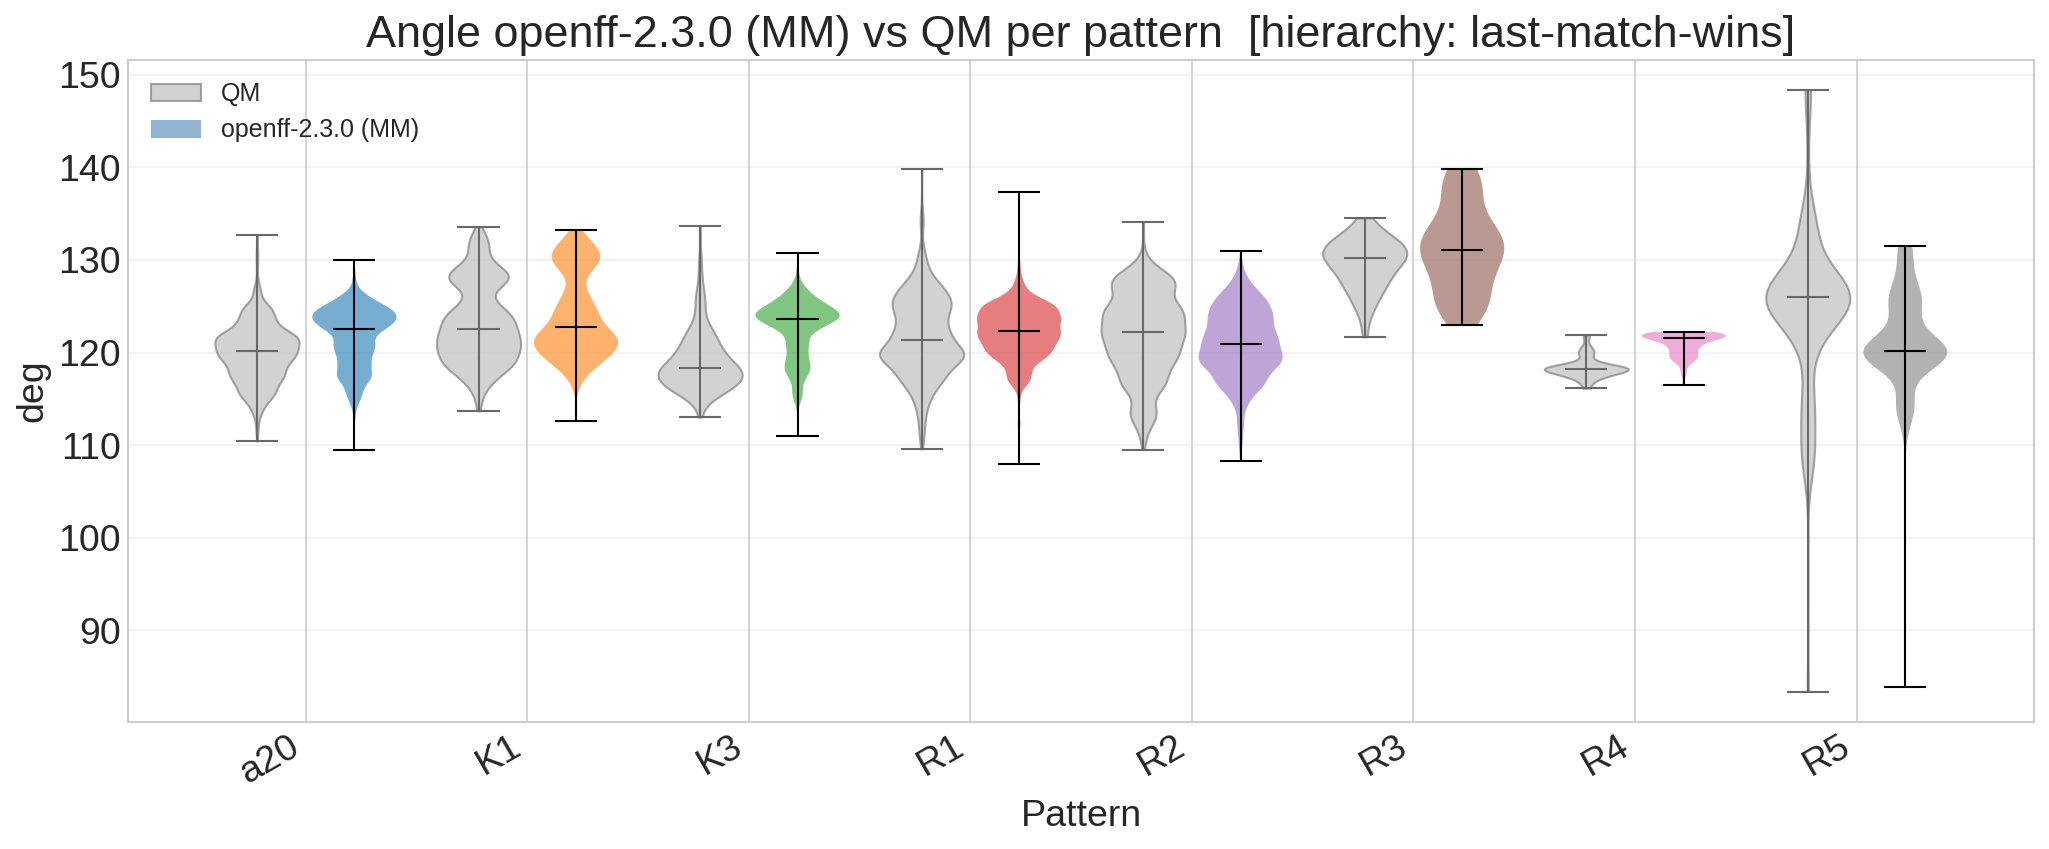

In [102]:
def run_hierarchy_overlay_analysis(
    bond_smarts_patterns=BOND_SMARTS_PATTERNS,
    angle_smarts_patterns=ANGLE_SMARTS_PATTERNS,
    data_files_override=DATA_FILES_OVERRIDE,
    forcefield_name=FORCEFIELD_NAME,
    ff_bond_param_ids=FF_BOND_PARAM_IDS,
    ff_angle_param_ids=FF_ANGLE_PARAM_IDS,
    high_error_only=HIGH_ERROR_ONLY,
):
    """Like run_overlay_analysis but with SMIRNOFF-style last-match-wins assignment.

    Patterns must be ordered most-general → most-specific (same order as an
    OpenFF ForceField SMIRKS list).  Each geometry instance (bond or angle) is
    assigned to the *last* pattern that matches it; more general patterns
    earlier in the list do not double-count instances already claimed by a
    later, more specific pattern.

    The summary table counts are therefore mutually exclusive — no instance
    appears in more than one pattern bucket.
    """
    config, bundles = load_bundles(
        QM_ROOT,
        OPTIMIZED_ROOT,
        POTENTIAL_NAME,
        data_files_override=data_files_override,
        cache_root=CACHE_ROOT,
        use_cache=USE_CACHE,
        force_rebuild_cache=FORCE_REBUILD_CACHE,
        bond_threshold=BOND_THRESHOLD,
        angle_threshold=ANGLE_THRESHOLD,
        torsion_threshold=TORSION_THRESHOLD,
        label_forcefield_name=forcefield_name,
    )
    analysis, summary = collect_hierarchy_overlay_data(
        bundles,
        bond_smarts_patterns,
        angle_smarts_patterns,
        POTENTIAL_NAME,
        metrics=METRICS,
        forcefield_name=forcefield_name,
        ff_bond_param_ids=ff_bond_param_ids,
        ff_angle_param_ids=ff_angle_param_ids,
        high_error_only=high_error_only,
    )

    display(Markdown('## Input summary'))
    input_rows = [
        {
            'dataset': bundle['dataset_name'],
            'records': len(bundle['records']),
            'optimized_sdf': str(bundle['optimized_sdf']),
        }
        for bundle in bundles
    ]
    display(pd.DataFrame(input_rows))

    # Show active filters
    filter_rows: list[dict] = [{'filter': 'assignment', 'value': 'hierarchy (last-match-wins)'}]
    if ff_angle_param_ids is not None:
        filter_rows.append({'filter': 'FF angle param IDs', 'value': ', '.join(sorted(ff_angle_param_ids))})
    if ff_bond_param_ids is not None:
        filter_rows.append({'filter': 'FF bond param IDs', 'value': ', '.join(sorted(ff_bond_param_ids))})
    if high_error_only:
        filter_rows.append({'filter': 'high_error_only', 'value': 'True (threshold-crossing instances only)'})
    display(Markdown('## Active filters'))
    display(pd.DataFrame(filter_rows))

    display(Markdown('## SMARTS hierarchy summary (counts are mutually exclusive)'))
    display(summary)

    for metric in METRICS:
        display(Markdown(f'### {metric_label(metric)}'))
        plot_actual_overlay(analysis, metric, hierarchy=True, potential_name=POTENTIAL_NAME)
        plot_qm_split_overlay(analysis, metric, hierarchy=True)
        plot_error_overlay(analysis, metric, hierarchy=True)
        plot_mm_qm_paired_overlay(analysis, metric, hierarchy=True, potential_name=POTENTIAL_NAME)

    return config, bundles, analysis, summary


# Uncomment to run hierarchy analysis with the patterns defined above.
# Patterns are assigned last-match-wins: Pattern N is most specific and wins
# over Pattern 1 (most general).  Counts in the summary are mutually exclusive.
#
config, bundles, h_analysis, h_summary = run_hierarchy_overlay_analysis(angle_smarts_patterns=ANGLE_SMARTS_PATTERNS)

### BESMARTS split inputs

The call below groups all matching angle examples for the parent SMARTS pattern into a few value-based clusters, then tries to describe each cluster with a child SMARTS.

- `PARENT_ANGLE_SMARTS`: the parent pattern to split. Here it is the phosphorus angle `[*:1]~[#15:2]~[*:3]`.
- `BESMARTS_MAX_K`: the maximum number of value clusters to try. Higher values can produce more, smaller groups.
- `BESMARTS_MIN_CLUSTER_SIZE`: the smallest number of angle examples allowed in any cluster. This keeps the split from overfitting tiny groups.
- `BESMARTS_DEPTH`: how much chemical neighborhood context to include when building each child SMARTS. `1` uses only the matched angle atoms and their immediate pattern context; `2` adds more neighboring chemistry and can produce more specific SMARTS.
- `recommended_smarts`: the output child SMARTS patterns that are ready to feed back into the overlay plots.

In [70]:
# import importlib
# import besmarts_angle_split as _besmarts_angle_split_mod
# importlib.reload(_besmarts_angle_split_mod)
# from besmarts_angle_split import propose_child_angle_smarts

# PARENT_ANGLE_SMARTS = '[*:1]~[#15:2]~[*:3]'
# BESMARTS_MAX_K = 6  # try 10 for more clusters; 0 means no upper limit on k
# BESMARTS_MIN_CLUSTER_SIZE = 80
# BESMARTS_DEPTH = 6  # neighbourhood depth for fragment intersection; try 2 for richer SMARTS

# split_result = propose_child_angle_smarts(
#     bundles,
#     PARENT_ANGLE_SMARTS,
#     max_k=BESMARTS_MAX_K,
#     min_cluster_size=BESMARTS_MIN_CLUSTER_SIZE,
#     depth=BESMARTS_DEPTH,
# )

# parent_df = split_result['parent_df']
# partition = split_result['partition']
# child_df = split_result['child_df'].copy()
# recommended_smarts = split_result['recommended_smarts']

# parent_summary = pd.DataFrame(
#     [
#         {'metric': 'parent_smarts', 'value': PARENT_ANGLE_SMARTS},
#         {'metric': 'n_entries', 'value': len(split_result['entries'])},
#         {'metric': 'n_unique_molecules', 'value': parent_df['molecule'].nunique()},
#         {'metric': 'chosen_k', 'value': partition['k']},
#         {'metric': 'rss', 'value': partition['rss']},
#         {'metric': 'bic', 'value': partition['bic']},
#     ]
# )

# display(Markdown('## BESMARTS parent-angle split summary'))
# display(parent_summary)

# display(Markdown('### Partition cluster statistics'))
# display(partition['clusters'])

# display(Markdown('### Derived child SMARTS'))
# display(child_df)

# if recommended_smarts:
#     display(Markdown('### Recommended child SMARTS for overlay'))
#     display(pd.DataFrame({'angle_smarts': recommended_smarts}))
# else:
#     display(Markdown(
#         '**No explicit child SMARTS were produced.** '
#         'All clusters yielded `None` from BESMARTS intersection — '
#         'try increasing `BESMARTS_DEPTH` to 2.'
#     ))

# RUN_CHILD_OVERLAY = bool(recommended_smarts)
# if RUN_CHILD_OVERLAY:
#     _, _, child_analysis, child_summary = run_overlay_analysis(
#         bond_smarts_patterns=[],
#         angle_smarts_patterns=recommended_smarts,
#         data_files_override=config.get('data_files', None),
#     )
#     display(Markdown('### Child SMARTS overlay summary'))
#     display(child_summary)
